In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import (
    classification_report,
    cohen_kappa_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform, randint
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss
import json

### Read in the data, create the target for the ML model, and check distributions

In [3]:
df = pd.read_csv("../data/processed/match_features_v1")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34549 entries, 0 to 34548
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            34549 non-null  int64  
 1   date                  34549 non-null  object 
 2   home_team             34549 non-null  object 
 3   away_team             34549 non-null  object 
 4   home_score            34549 non-null  float64
 5   away_score            34549 non-null  float64
 6   city                  34549 non-null  object 
 7   country               34549 non-null  object 
 8   neutral               34549 non-null  bool   
 9   tournament_code       29840 non-null  object 
 10  tournament            29840 non-null  object 
 11  home_elo              29840 non-null  float64
 12  away_elo              29840 non-null  float64
 13  home_ranking          29840 non-null  float64
 14  away_ranking          29840 non-null  float64
 15  match_id           

In [5]:
df = df.drop(columns=["Unnamed: 0"])

In [6]:
match_id = df.pop("match_id")
df.insert(0, "match_id", match_id)

In [7]:
df.tail(5) 

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,elo_difference,rank_difference,home_last5_W,home_last5_L,home_last5_scoring,home_last5_conceding,away_last5_W,away_last5_L,away_last5_scoring,away_last5_conceding
34544,34544,2026-07-11,Argentina,Switzerland,3.0,1.0,Kansas City,United States,True,WC,...,249.0,9.0,1.0,0.0,2.8,1.0,0.6,0.0,1.8,0.6
34545,34545,2026-07-14,France,Spain,0.0,2.0,Arlington,United States,True,WC,...,-111.0,-2.0,1.0,0.0,2.6,0.2,1.0,0.0,2.2,0.2
34546,34546,2026-07-15,England,Argentina,1.0,2.0,Atlanta,United States,True,WC,...,-126.0,-2.0,0.8,0.0,1.8,0.8,1.0,0.0,2.8,1.2
34547,34547,2026-07-18,France,England,4.0,6.0,Miami Gardens,United States,True,WC,...,-55.0,-1.0,0.8,0.2,2.0,0.6,0.8,0.2,2.0,1.2
34548,34548,2026-07-19,Spain,Argentina,1.0,0.0,East Rutherford,United States,True,WC,...,86.0,1.0,1.0,0.0,1.8,0.2,1.0,0.0,2.8,1.4


In [8]:
df["date"] = pd.to_datetime(df["date"])

In [9]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34549 entries, 0 to 34548
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   match_id              34549 non-null  int64         
 1   date                  34549 non-null  datetime64[ns]
 2   home_team             34549 non-null  object        
 3   away_team             34549 non-null  object        
 4   home_score            34549 non-null  float64       
 5   away_score            34549 non-null  float64       
 6   city                  34549 non-null  object        
 7   country               34549 non-null  object        
 8   neutral               34549 non-null  bool          
 9   tournament_code       29840 non-null  object        
 10  tournament            29840 non-null  object        
 11  home_elo              29840 non-null  float64       
 12  away_elo              29840 non-null  float64       
 13  home_ranking    

In [10]:
df.head(5)

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,elo_difference,rank_difference,home_last5_W,home_last5_L,home_last5_scoring,home_last5_conceding,away_last5_W,away_last5_L,away_last5_scoring,away_last5_conceding
0,0,1872-11-30,Scotland,England,0.0,0.0,Glasgow,Scotland,False,F,...,-6.0,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1873-03-08,England,Scotland,4.0,2.0,London,England,False,F,...,28.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1874-03-07,Scotland,England,2.0,1.0,Glasgow,Scotland,False,F,...,-12.0,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1875-03-06,England,Scotland,2.0,2.0,London,England,False,F,...,6.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1876-03-04,Scotland,England,3.0,0.0,Glasgow,Scotland,False,F,...,20.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df["target"] = ""

df.loc[df["home_score"] > df["away_score"], "target"] = "home_win"
df.loc[df["home_score"] == df["away_score"], "target"] = "draw"
df.loc[df["home_score"] < df["away_score"], "target"] = "away_win"

In [12]:
df[df["target"] == ""]

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,rank_difference,home_last5_W,home_last5_L,home_last5_scoring,home_last5_conceding,away_last5_W,away_last5_L,away_last5_scoring,away_last5_conceding,target


In [13]:
df["target"].value_counts() 

target
home_win    16895
away_win     9503
draw         8151
Name: count, dtype: int64

<Axes: xlabel='target', ylabel='count'>

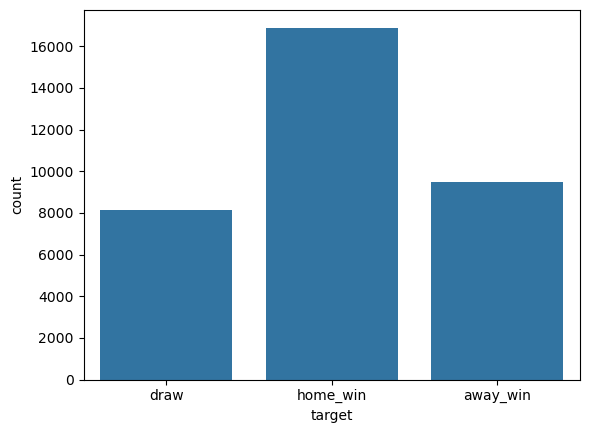

In [14]:
sns.countplot(data=df, x = "target")

### Temporal Data cutoff - 1980/2000, allocate splits for training and validation.

In [15]:
df_2000 = df.copy() 

df_2000 = df_2000[df_2000["date"] >= "2000-01-01"]

df_2000.shape



(19119, 26)

In [16]:
df_2000 = df.copy() 
df_2000 = df_2000[df_2000["date"] >= "2000-01-01"]

df_1980 = df.copy()
df_1980 = df_1980[df_1980["date"] >= "1980-01-01"]

In [17]:
df_2000 = df_2000.sort_values(by="date")
df_1980 = df_1980.sort_values(by="date") 

In [18]:
n_2000 = len(df_2000)  # set the length to the length of the df
date_2000_70 = int(n_2000 * 0.70) #then 70% is allocated to training 
date_2000_85 = int(n_2000 * 0.85)  #15 % validate 

n_1980 = len(df_1980)
date_1980_70 = int(n_1980 * 0.70)
date_1980_85 = int(n_1980 * 0.85)


In [19]:
row_70 = df_2000.iloc[date_2000_70]["date"]
print(f" 70% for 2000 dataset is: {row_70}")
row_85 = df_2000.iloc[date_2000_85]["date"]
print(f" 85% for 2000 dataset is: {row_85}") 


 70% for 2000 dataset is: 2018-02-28 00:00:00
 85% for 2000 dataset is: 2022-09-21 00:00:00


In [20]:
row_70_1980 = df_1980.iloc[date_1980_70]["date"]
print(f" 70% for 1980 dataset is: {row_70_1980}")
row_85_1980 = df_1980.iloc[date_1980_85]["date"]
print(f" 85% for 1980 dataset is: {row_85_1980}") 

 70% for 1980 dataset is: 2014-10-11 00:00:00
 85% for 1980 dataset is: 2021-03-27 00:00:00


In [21]:
df_1980.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27381 entries, 7168 to 34548
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   match_id              27381 non-null  int64         
 1   date                  27381 non-null  datetime64[ns]
 2   home_team             27381 non-null  object        
 3   away_team             27381 non-null  object        
 4   home_score            27381 non-null  float64       
 5   away_score            27381 non-null  float64       
 6   city                  27381 non-null  object        
 7   country               27381 non-null  object        
 8   neutral               27381 non-null  bool          
 9   tournament_code       24862 non-null  object        
 10  tournament            24862 non-null  object        
 11  home_elo              24862 non-null  float64       
 12  away_elo              24862 non-null  float64       
 13  home_ranking      

In [22]:
df_1980.head(5) 

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,rank_difference,home_last5_W,home_last5_L,home_last5_scoring,home_last5_conceding,away_last5_W,away_last5_L,away_last5_scoring,away_last5_conceding,target
7168,7168,1980-01-06,Sierra Leone,Ghana,2.0,4.0,Freetown,Sierra Leone,False,F,...,-49.0,0.4,0.4,1.0,1.8,0.4,0.4,0.8,1.2,away_win
7169,7169,1980-01-16,Cyprus,Greece,1.0,1.0,Nicosia,Cyprus,False,F,...,-87.0,0.0,0.8,0.4,2.4,0.2,0.4,0.8,1.8,draw
7170,7170,1980-01-19,Congo,Ivory Coast,2.0,0.0,Brazzaville,Congo,False,F,...,10.0,0.6,0.4,1.8,2.0,0.6,0.4,2.0,0.8,home_win
7171,7171,1980-01-20,Congo,Ivory Coast,0.0,2.0,Brazzaville,Congo,False,F,...,2.0,0.8,0.2,2.2,1.4,0.6,0.4,2.0,0.8,away_win
7172,7172,1980-01-23,Spain,Netherlands,1.0,0.0,Vigo,Spain,False,F,...,-8.0,0.2,0.4,1.4,1.6,0.6,0.2,1.8,0.6,home_win


In [23]:
df_2000.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19119 entries, 15430 to 34548
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   match_id              19119 non-null  int64         
 1   date                  19119 non-null  datetime64[ns]
 2   home_team             19119 non-null  object        
 3   away_team             19119 non-null  object        
 4   home_score            19119 non-null  float64       
 5   away_score            19119 non-null  float64       
 6   city                  19119 non-null  object        
 7   country               19119 non-null  object        
 8   neutral               19119 non-null  bool          
 9   tournament_code       17957 non-null  object        
 10  tournament            17957 non-null  object        
 11  home_elo              17957 non-null  float64       
 12  away_elo              17957 non-null  float64       
 13  home_ranking     

In [24]:
df_2000[(df_2000["home_team"] == "Switzerland") & (df_2000["away_team"] == "Colombia") & (df_2000["date"] == "2026-07-07")]

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,rank_difference,home_last5_W,home_last5_L,home_last5_scoring,home_last5_conceding,away_last5_W,away_last5_L,away_last5_scoring,away_last5_conceding,target
34540,34540,2026-07-07,Switzerland,Colombia,0.0,0.0,Vancouver,Canada,True,WC,...,-6.0,0.6,0.0,2.0,0.8,0.8,0.0,1.4,0.2,draw


In [25]:
df_1980 = pd.get_dummies(df_1980, columns = ["tournament"], dtype=int)
df_2000 = pd.get_dummies(df_2000, columns = ["tournament"], dtype=int)

In [26]:
df_1980["abs_rank_diff"] = df_1980["rank_difference"].copy() 
df_1980["abs_elo_diff"] = df_1980["elo_difference"].copy()

df_2000["abs_rank_diff"] = df_2000["rank_difference"].copy() 
df_2000["abs_elo_diff"] = df_2000["elo_difference"].copy()

df_1980["abs_rank_diff"] = df_1980["rank_difference"].abs()
df_1980["abs_elo_diff"] = df_1980["elo_difference"].abs() 

df_2000["abs_rank_diff"] = df_2000["rank_difference"].abs()
df_2000["abs_elo_diff"] = df_2000["elo_difference"].abs()


### Temporal Train / Validation  / Test split 

In [27]:
train_date = "2018-01-01"
val_date = "2022-01-01" 

train_data_2000 = df_2000[(df_2000["date"]) < train_date]
val_data_2000 = df_2000[(df_2000["date"] >= train_date) & (df_2000["date"] < val_date)]
test_data_2000 = df_2000[(df_2000["date"] >= val_date)]

train_data_1980 = df_1980[(df_1980["date"]) < train_date]
val_data_1980 = df_1980[(df_1980["date"] >= train_date) & (df_1980["date"] < val_date)]
test_data_1980 = df_1980[(df_1980["date"] >= val_date)]

shape_2000_train = train_data_2000.shape
shape_2000_val = val_data_2000.shape
shape_2000_test = test_data_2000.shape

shape_1980_train = train_data_1980.shape
shape_1980_val = val_data_1980.shape
shape_1980_test = test_data_1980.shape

print(f"2000s training data: {shape_2000_train}")
print(f"2000s validation data: {shape_2000_val}")
print(f"2000s test data: {shape_2000_test}")
print("\n") 
print(f"1980s training data: {shape_1980_train}")
print(f"1980s validation data: {shape_1980_val}")
print(f"1980s test data: {shape_1980_test}")

2000s training data: (13371, 42)
2000s validation data: (2492, 42)
2000s test data: (3256, 42)


1980s training data: (21633, 42)
1980s validation data: (2492, 42)
1980s test data: (3256, 42)


### Ensuring that end-dates are appropiate for train/validation/test across 1980/2000


In [28]:
train_data_1980.tail(5) 

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,tournament_FIFA World Cup qualification,tournament_Friendly,tournament_Gold Cup,tournament_Gold Cup qualification,tournament_Oceania Nations Cup,tournament_Oceania Nations Cup qualification,tournament_UEFA Euro,tournament_UEFA Euro qualification,abs_rank_diff,abs_elo_diff
28796,28796,2017-12-05,Taiwan,Laos,2.0,0.0,Taipei,Taiwan,False,NaN,...,0,0,0,0,0,0,0,0,NaN,NaN
28797,28797,2017-12-06,Indonesia,Kyrgyzstan,0.0,1.0,Banda Aceh,Indonesia,False,NaN,...,0,0,0,0,0,0,0,0,NaN,NaN
28798,28798,2017-12-14,Qatar,Liechtenstein,1.0,2.0,Doha,Qatar,False,F,...,0,1,0,0,0,0,0,0,75.0,290.0
28799,28799,2017-12-18,Bahrain,Kuwait,0.0,0.0,Riffa,Bahrain,False,F,...,0,1,0,0,0,0,0,0,20.0,68.0
28800,28800,2017-12-25,Jordan,Libya,1.0,1.0,Amman,Jordan,False,F,...,0,1,0,0,0,0,0,0,4.0,9.0


In [29]:
val_data_1980.tail(5) 

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,tournament_FIFA World Cup qualification,tournament_Friendly,tournament_Gold Cup,tournament_Gold Cup qualification,tournament_Oceania Nations Cup,tournament_Oceania Nations Cup qualification,tournament_UEFA Euro,tournament_UEFA Euro qualification,abs_rank_diff,abs_elo_diff
31288,31288,2021-12-08,Mexico,Chile,2.0,2.0,Austin,United States,True,F,...,0,1,0,0,0,0,0,0,7.0,49.0
31289,31289,2021-12-09,Tanzania,Uganda,0.0,2.0,Dar es Salaam,Tanzania,False,F,...,0,1,0,0,0,0,0,0,42.0,151.0
31290,31290,2021-12-11,El Salvador,Chile,0.0,1.0,Los Angeles,United States,True,F,...,0,1,0,0,0,0,0,0,56.0,294.0
31291,31291,2021-12-18,United States,Bosnia and Herzegovina,1.0,0.0,Los Angeles,United States,False,F,...,0,1,0,0,0,0,0,0,49.0,258.0
31292,31292,2021-12-30,Sudan,Ethiopia,2.0,3.0,Limbé,Cameroon,True,F,...,0,1,0,0,0,0,0,0,13.0,37.0


In [30]:
test_data_1980.tail(5) 

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,tournament_FIFA World Cup qualification,tournament_Friendly,tournament_Gold Cup,tournament_Gold Cup qualification,tournament_Oceania Nations Cup,tournament_Oceania Nations Cup qualification,tournament_UEFA Euro,tournament_UEFA Euro qualification,abs_rank_diff,abs_elo_diff
34544,34544,2026-07-11,Argentina,Switzerland,3.0,1.0,Kansas City,United States,True,WC,...,0,0,0,0,0,0,0,0,9.0,249.0
34545,34545,2026-07-14,France,Spain,0.0,2.0,Arlington,United States,True,WC,...,0,0,0,0,0,0,0,0,2.0,111.0
34546,34546,2026-07-15,England,Argentina,1.0,2.0,Atlanta,United States,True,WC,...,0,0,0,0,0,0,0,0,2.0,126.0
34547,34547,2026-07-18,France,England,4.0,6.0,Miami Gardens,United States,True,WC,...,0,0,0,0,0,0,0,0,1.0,55.0
34548,34548,2026-07-19,Spain,Argentina,1.0,0.0,East Rutherford,United States,True,WC,...,0,0,0,0,0,0,0,0,1.0,86.0


In [31]:
train_data_2000.tail(5) 

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,tournament_FIFA World Cup qualification,tournament_Friendly,tournament_Gold Cup,tournament_Gold Cup qualification,tournament_Oceania Nations Cup,tournament_Oceania Nations Cup qualification,tournament_UEFA Euro,tournament_UEFA Euro qualification,abs_rank_diff,abs_elo_diff
28796,28796,2017-12-05,Taiwan,Laos,2.0,0.0,Taipei,Taiwan,False,NaN,...,0,0,0,0,0,0,0,0,NaN,NaN
28797,28797,2017-12-06,Indonesia,Kyrgyzstan,0.0,1.0,Banda Aceh,Indonesia,False,NaN,...,0,0,0,0,0,0,0,0,NaN,NaN
28798,28798,2017-12-14,Qatar,Liechtenstein,1.0,2.0,Doha,Qatar,False,F,...,0,1,0,0,0,0,0,0,75.0,290.0
28799,28799,2017-12-18,Bahrain,Kuwait,0.0,0.0,Riffa,Bahrain,False,F,...,0,1,0,0,0,0,0,0,20.0,68.0
28800,28800,2017-12-25,Jordan,Libya,1.0,1.0,Amman,Jordan,False,F,...,0,1,0,0,0,0,0,0,4.0,9.0


In [32]:
val_data_2000.tail(5) 

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,tournament_FIFA World Cup qualification,tournament_Friendly,tournament_Gold Cup,tournament_Gold Cup qualification,tournament_Oceania Nations Cup,tournament_Oceania Nations Cup qualification,tournament_UEFA Euro,tournament_UEFA Euro qualification,abs_rank_diff,abs_elo_diff
31288,31288,2021-12-08,Mexico,Chile,2.0,2.0,Austin,United States,True,F,...,0,1,0,0,0,0,0,0,7.0,49.0
31289,31289,2021-12-09,Tanzania,Uganda,0.0,2.0,Dar es Salaam,Tanzania,False,F,...,0,1,0,0,0,0,0,0,42.0,151.0
31290,31290,2021-12-11,El Salvador,Chile,0.0,1.0,Los Angeles,United States,True,F,...,0,1,0,0,0,0,0,0,56.0,294.0
31291,31291,2021-12-18,United States,Bosnia and Herzegovina,1.0,0.0,Los Angeles,United States,False,F,...,0,1,0,0,0,0,0,0,49.0,258.0
31292,31292,2021-12-30,Sudan,Ethiopia,2.0,3.0,Limbé,Cameroon,True,F,...,0,1,0,0,0,0,0,0,13.0,37.0


In [33]:
test_data_2000.tail(5) 

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,tournament_FIFA World Cup qualification,tournament_Friendly,tournament_Gold Cup,tournament_Gold Cup qualification,tournament_Oceania Nations Cup,tournament_Oceania Nations Cup qualification,tournament_UEFA Euro,tournament_UEFA Euro qualification,abs_rank_diff,abs_elo_diff
34544,34544,2026-07-11,Argentina,Switzerland,3.0,1.0,Kansas City,United States,True,WC,...,0,0,0,0,0,0,0,0,9.0,249.0
34545,34545,2026-07-14,France,Spain,0.0,2.0,Arlington,United States,True,WC,...,0,0,0,0,0,0,0,0,2.0,111.0
34546,34546,2026-07-15,England,Argentina,1.0,2.0,Atlanta,United States,True,WC,...,0,0,0,0,0,0,0,0,2.0,126.0
34547,34547,2026-07-18,France,England,4.0,6.0,Miami Gardens,United States,True,WC,...,0,0,0,0,0,0,0,0,1.0,55.0
34548,34548,2026-07-19,Spain,Argentina,1.0,0.0,East Rutherford,United States,True,WC,...,0,0,0,0,0,0,0,0,1.0,86.0


### Inspecting to see if there exists any fundamental differences between validation and test



In [34]:
val_draw_insp = val_data_2000[["home_elo", "away_elo", "home_ranking", "away_ranking", 
                          "elo_difference", "rank_difference", "home_last5_W",
                          "home_last5_L", "home_last5_scoring", "home_last5_conceding", 
                          "away_last5_W", "away_last5_L", "away_last5_scoring",
                          "away_last5_conceding", "target", "neutral"]]

test_draw_insp = test_data_2000[["home_elo", "away_elo", "home_ranking", "away_ranking", 
                          "elo_difference", "rank_difference", "home_last5_W",
                          "home_last5_L", "home_last5_scoring", "home_last5_conceding", 
                          "away_last5_W", "away_last5_L", "away_last5_scoring",
                          "away_last5_conceding", "target", "neutral"]]


val_draw_insp = val_draw_insp.dropna()
test_draw_insp = test_draw_insp.dropna() 


val_draw_insp[val_draw_insp["target"] == "draw" ]

,home_elo,away_elo,home_ranking,away_ranking,elo_difference,rank_difference,home_last5_W,home_last5_L,home_last5_scoring,home_last5_conceding,away_last5_W,away_last5_L,away_last5_scoring,away_last5_conceding,target,neutral
28801,1513.0,1816.0,79.0,20.0,-303.0,-59.0,0.6,0.2,1.4,0.8,0.6,0.2,2.6,0.4,draw,True
28807,1747.0,1727.0,27.0,36.0,20.0,9.0,0.2,0.4,1.4,1.2,0.4,0.4,2.2,1.6,draw,False
28808,1398.0,1330.0,109.0,122.0,68.0,13.0,0.2,0.8,1.4,2.2,0.0,1.0,0.0,1.8,draw,True
28809,1569.0,1757.0,69.0,25.0,-188.0,-44.0,0.4,0.6,1.2,2.0,0.4,0.4,1.4,1.8,draw,True
28820,1365.0,1379.0,119.0,113.0,-14.0,-6.0,0.6,0.2,1.8,2.0,0.4,0.6,1.6,0.8,draw,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31258,1643.0,1467.0,51.0,87.0,176.0,36.0,0.8,0.2,1.6,0.4,0.6,0.2,1.4,1.0,draw,False
31267,1505.0,1734.0,81.0,33.0,-229.0,-48.0,0.2,0.6,1.2,2.0,0.6,0.2,1.6,0.6,draw,True
31262,1330.0,1359.0,123.0,111.0,-29.0,-12.0,0.4,0.6,0.6,1.2,0.2,0.6,1.0,1.4,draw,False
31287,1502.0,1848.0,82.0,16.0,-346.0,-66.0,0.0,0.8,0.6,1.6,0.6,0.2,1.4,0.8,draw,True


In [35]:
test_draw_insp[test_draw_insp["target"] == "draw" ]

,home_elo,away_elo,home_ranking,away_ranking,elo_difference,rank_difference,home_last5_W,home_last5_L,home_last5_scoring,home_last5_conceding,away_last5_W,away_last5_L,away_last5_scoring,away_last5_conceding,target,neutral
31294,1309.0,1311.0,131.0,130.0,-2.0,-1.0,0.0,0.4,1.0,1.8,0.0,0.8,0.4,1.4,draw,True
31304,1315.0,1382.0,129.0,106.0,-67.0,-23.0,0.0,0.4,0.8,1.6,0.2,0.4,0.8,2.0,draw,True
31305,1785.0,1356.0,28.0,113.0,429.0,85.0,0.8,0.0,3.8,0.6,0.4,0.0,0.8,0.4,draw,True
31306,1544.0,1460.0,71.0,88.0,84.0,17.0,0.2,0.4,1.2,1.6,0.6,0.2,1.0,0.4,draw,True
31311,1690.0,1432.0,43.0,92.0,258.0,49.0,0.8,0.0,2.2,0.6,0.4,0.4,0.6,1.2,draw,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34513,2004.0,1990.0,6.0,7.0,14.0,1.0,0.8,0.2,2.0,1.0,0.8,0.0,2.4,0.6,draw,True
34519,1908.0,1823.0,12.0,24.0,85.0,12.0,0.8,0.2,3.2,1.0,0.4,0.4,1.4,1.2,draw,True
34520,1971.0,1886.0,8.0,16.0,85.0,8.0,0.6,0.2,2.4,1.2,0.6,0.0,2.2,0.8,draw,True
34530,1795.0,1747.0,26.0,33.0,48.0,7.0,0.2,0.4,0.6,0.8,0.4,0.2,1.4,1.0,draw,True


### Experimental ranking similarity feature 

Tested whether encoding team closeness from absolute ranking difference would improve the recall, precision, and f1 score for a target class of "draw". Ultimately, it did not add any meaningful signal and was not included in the final feature set 

In [36]:
closeness = [0.90, 0.80, 0.65, 0.55, 0.35, 0.25, 0.15, 0.05]

condition_1980 = [

    (df_1980["abs_rank_diff"] <= 25), # 0.90 
    (df_1980["abs_rank_diff"] > 25) & (df_1980["abs_rank_diff"] <= 50), #26 - 50 = 0.80f
    (df_1980["abs_rank_diff"] > 50) & (df_1980["abs_rank_diff"] <= 75),  #51 - 75 = 0.65
    (df_1980["abs_rank_diff"] > 75) & (df_1980["abs_rank_diff"] <= 100), #76 - 100 = 0.55 
    (df_1980["abs_rank_diff"] > 100) & (df_1980["abs_rank_diff"] <= 125),  #101 - 125 = 0.35 
    (df_1980["abs_rank_diff"] > 125) & (df_1980["abs_rank_diff"] <= 150), #126 - 150 = 0.25 
    (df_1980["abs_rank_diff"] > 150) & (df_1980["abs_rank_diff"] <= 175), #151- 175 = 0.15
    (df_1980["abs_rank_diff"] > 175) # 176+  0.05
]

condition_2000 = [

    (df_2000["abs_rank_diff"] <= 25), # 0.90 
    (df_2000["abs_rank_diff"] > 25) & (df_2000["abs_rank_diff"] <= 50), #26 - 50 = 0.80f
    (df_2000["abs_rank_diff"] > 50) & (df_2000["abs_rank_diff"] <= 75),  #51 - 75 = 0.65
    (df_2000["abs_rank_diff"] > 75) & (df_2000["abs_rank_diff"] <= 100), #76 - 100 = 0.55 
    (df_2000["abs_rank_diff"] > 100) & (df_2000["abs_rank_diff"] <= 125),  #101 - 125 = 0.35 
    (df_2000["abs_rank_diff"] > 125) & (df_2000["abs_rank_diff"] <= 150), #126 - 150 = 0.25 
    (df_2000["abs_rank_diff"] > 150) & (df_2000["abs_rank_diff"] <= 175), #151- 175 = 0.15
    (df_2000["abs_rank_diff"] > 175) # 176+  0.05
]

df_1980["similarity_scale"] = np.select(condition_1980, closeness)
df_2000["similarity_scale"] = np.select(condition_2000, closeness) 

In [37]:
eda_df = train_data_2000.copy()

eda_df = eda_df.drop(columns = [
    "match_id", "city", "country", 
    "tournament_code", "neutral"
    ""
])

avg_elo_draw = eda_df.loc[eda_df["target"] == "draw", "elo_difference"].abs().mean()
print(f"average elo difference for matches that ended in draws: {avg_elo_draw:.2f}")
avg_rank_draw = eda_df.loc[eda_df["target"] == "draw", "rank_difference"].abs().mean()
print(f"average rank difference for matches that ended in draws: {avg_rank_draw:.2f}")

print("\n")

avg_elo_hwin = eda_df.loc[eda_df["target"] == "home_win", "elo_difference"].abs().mean()
print(f"average elo difference for matches that ended in home wins: {avg_elo_hwin:.2f}")
avg_rank_hwin = eda_df.loc[eda_df["target"] == "home_win", "rank_difference"].abs().mean()
print(f"average rank difference for matches that ended in home wins: {avg_rank_hwin:.2f}")

print("\n")

avg_elo_awin = eda_df.loc[eda_df["target"] == "away_win", "elo_difference"].abs().mean()
print(f"average elo difference for matches that ended in away wins: {avg_elo_awin:.2f}")
avg_rank_awin = eda_df.loc[eda_df["target"] == "away_win", "rank_difference"].abs().mean()
print(f"average rank difference for matches that ended in home wins: {avg_rank_awin:.2f}")

      

average elo difference for matches that ended in draws: 154.41
average rank difference for matches that ended in draws: 30.56


average elo difference for matches that ended in home wins: 228.47
average rank difference for matches that ended in home wins: 44.65


average elo difference for matches that ended in away wins: 253.68
average rank difference for matches that ended in home wins: 49.56


In [38]:
#Creating a non-signed representation of both rank and elo difference

eda_df["abs_rank_diff"] = eda_df["rank_difference"].copy() 
eda_df["abs_elo_diff"] = eda_df["elo_difference"].copy()

eda_df["abs_rank_diff"] = eda_df["abs_rank_diff"].abs()
eda_df["abs_elo_diff"] = eda_df["abs_elo_diff"].abs()


#Creating a column that specifically represents whether a match ended in a draw.

eda_df["draw_flag"] = eda_df["target"].copy()

eda_df.loc[(eda_df["draw_flag"] == "home_win") | (eda_df["draw_flag"] == "away_win"), "draw_flag"] = 0 
eda_df.loc[(eda_df["draw_flag"] == "draw"), "draw_flag"] = 1

eda_df["draw_flag"] = eda_df["draw_flag"].astype(int) 


In [39]:
eda_df.shape

(13371, 38)

In [40]:
eda_df["abs_elo_diff"].max() 

eda_df[eda_df["abs_elo_diff"].between(501, 700)].count()

date                                               652
home_team                                          652
away_team                                          652
home_score                                         652
away_score                                         652
home_elo                                           652
away_elo                                           652
home_ranking                                       652
away_ranking                                       652
elo_difference                                     652
rank_difference                                    652
home_last5_W                                       645
home_last5_L                                       645
home_last5_scoring                                 645
home_last5_conceding                               645
away_last5_W                                       644
away_last5_L                                       644
away_last5_scoring                                 644
away_last5

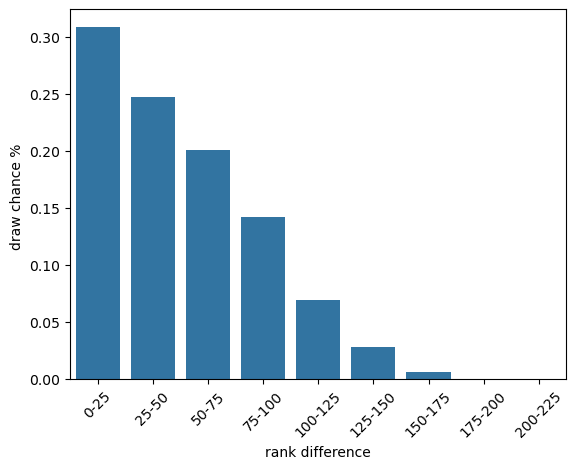

In [41]:
rank_bins = range(0, 250, 25)
rank_labels = [f'{i}-{i+25}' for i in range(0, 225, 25)]


eda_df["bins_rank"] = pd.cut(eda_df["abs_rank_diff"], bins = rank_bins, labels = rank_labels)
sns.barplot(data = eda_df, x = "bins_rank", y = "draw_flag", errorbar = None)
plt.xticks(rotation=45)
plt.xlabel("rank difference")
plt.ylabel("draw chance % ")
plt.show() 



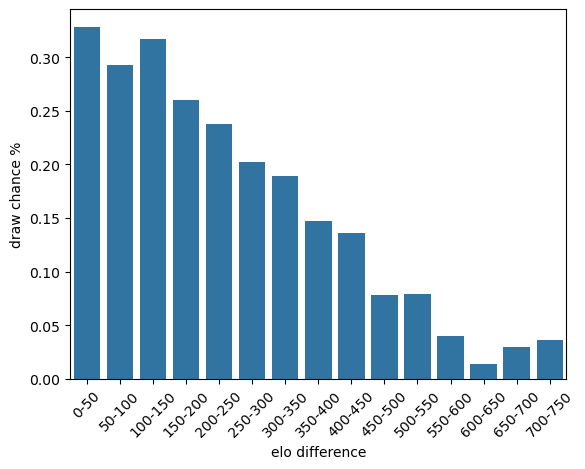

In [42]:
elo_bins = range(0, 800, 50)
elo_labels = [f'{i}-{i+50}' for i in range(0, 750, 50)]


eda_df["bins_elo"] = pd.cut(eda_df["abs_elo_diff"], bins = elo_bins, labels = elo_labels)
sns.barplot(data = eda_df, x = "bins_elo", y = "draw_flag", errorbar = None)
plt.xticks(rotation=45)
plt.xlabel("elo difference")
plt.ylabel("draw chance %")
plt.show() 


In [43]:
eda_df.head(5) 

,date,home_team,away_team,home_score,away_score,home_elo,away_elo,home_ranking,away_ranking,elo_difference,...,tournament_Gold Cup qualification,tournament_Oceania Nations Cup,tournament_Oceania Nations Cup qualification,tournament_UEFA Euro,tournament_UEFA Euro qualification,abs_rank_diff,abs_elo_diff,draw_flag,bins_rank,bins_elo
15430,2000-01-04,Egypt,Togo,2.0,1.0,1630.0,1334.0,50.0,122.0,296.0,...,0,0,0,0,0,72.0,296.0,0,50-75,250-300
15431,2000-01-07,Tunisia,Togo,7.0,0.0,1648.0,1330.0,44.0,122.0,318.0,...,0,0,0,0,0,78.0,318.0,0,75-100,300-350
15432,2000-01-08,Trinidad and Tobago,Canada,0.0,0.0,1580.0,1570.0,59.0,62.0,10.0,...,0,0,0,0,0,3.0,10.0,1,0-25,0-50
15433,2000-01-09,Burkina Faso,Gabon,1.0,1.0,1421.0,1459.0,102.0,90.0,-38.0,...,0,0,0,0,0,12.0,38.0,1,0-25,0-50
15434,2000-01-09,Guatemala,Armenia,1.0,1.0,1551.0,1375.0,68.0,113.0,176.0,...,0,0,0,0,0,45.0,176.0,1,25-50,150-200


In [44]:
test_data_2000[test_data_2000["target"] == "draw"]

,match_id,date,home_team,away_team,home_score,away_score,city,country,neutral,tournament_code,...,tournament_FIFA World Cup qualification,tournament_Friendly,tournament_Gold Cup,tournament_Gold Cup qualification,tournament_Oceania Nations Cup,tournament_Oceania Nations Cup qualification,tournament_UEFA Euro,tournament_UEFA Euro qualification,abs_rank_diff,abs_elo_diff
31294,31294,2022-01-02,Sudan,Zimbabwe,0.0,0.0,Yaoundé,Cameroon,True,F,...,0,1,0,0,0,0,0,0,1.0,2.0
31304,31304,2022-01-11,Sudan,Guinea-Bissau,0.0,0.0,Garoua,Cameroon,True,AR,...,0,0,0,0,0,0,0,0,23.0,67.0
31305,31305,2022-01-11,Algeria,Sierra Leone,0.0,0.0,Douala,Cameroon,True,AR,...,0,0,0,0,0,0,0,0,85.0,429.0
31306,31306,2022-01-12,Iceland,Uganda,1.0,1.0,Belek,Turkey,True,F,...,0,1,0,0,0,0,0,0,17.0,84.0
31311,31311,2022-01-14,Senegal,Guinea,0.0,0.0,Bafoussam,Cameroon,True,AR,...,0,0,0,0,0,0,0,0,49.0,258.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34513,34513,2026-06-27,Colombia,Portugal,0.0,0.0,Miami Gardens,United States,True,WC,...,0,0,0,0,0,0,0,0,1.0,14.0
34519,34519,2026-06-29,Germany,Paraguay,1.0,1.0,Foxborough,United States,True,WC,...,0,0,0,0,0,0,0,0,12.0,85.0
34520,34520,2026-06-29,Netherlands,Morocco,1.0,1.0,Guadalupe,Mexico,True,WC,...,0,0,0,0,0,0,0,0,8.0,85.0
34530,34530,2026-07-03,Australia,Egypt,1.0,1.0,Arlington,United States,True,WC,...,0,0,0,0,0,0,0,0,7.0,48.0


In [45]:
df_2000.columns

Index(['match_id', 'date', 'home_team', 'away_team', 'home_score',
       'away_score', 'city', 'country', 'neutral', 'tournament_code',
       'home_elo', 'away_elo', 'home_ranking', 'away_ranking',
       'elo_difference', 'rank_difference', 'home_last5_W', 'home_last5_L',
       'home_last5_scoring', 'home_last5_conceding', 'away_last5_W',
       'away_last5_L', 'away_last5_scoring', 'away_last5_conceding', 'target',
       'tournament_AFC Asian Cup', 'tournament_AFC Asian Cup qualification',
       'tournament_African Cup of Nations',
       'tournament_African Cup of Nations qualification',
       'tournament_Copa América', 'tournament_Copa América qualification',
       'tournament_FIFA World Cup', 'tournament_FIFA World Cup qualification',
       'tournament_Friendly', 'tournament_Gold Cup',
       'tournament_Gold Cup qualification', 'tournament_Oceania Nations Cup',
       'tournament_Oceania Nations Cup qualification', 'tournament_UEFA Euro',
       'tournament_UEFA Euro qual

In [46]:
df_2000.shape

(19119, 43)

In [47]:
train_data_2000 = train_data_2000.dropna() 
val_data_2000 = val_data_2000.dropna()
test_data_2000 = test_data_2000.dropna()


train_data_1980 = train_data_1980.dropna()
val_data_1980 = val_data_1980.dropna()
test_data_1980 = test_data_1980.dropna()


### Checking if there are any differneces in tournament distribution across my test and validation data 

In [48]:
val_data_1980["tournament_code"].value_counts() 

tournament_code
F      847
WQ     565
EQ     243
FQ     232
WQS    165
WC      64
CA      54
CCH     53
AC      51
EC      51
AR      46
SQ      16
CCQ      5
Name: count, dtype: int64

In [49]:
test_data_2000["tournament_code"].value_counts() 

tournament_code
F      1113
WQ      811
FQ      257
EQ      221
WC      168
AR      137
WQS     125
SQ       99
CCH      53
AC       51
EC       51
CA       32
CCQ      13
OC        6
OCQ       3
CAQ       2
Name: count, dtype: int64

In [50]:
eda_df.isna().sum() 

date                                                  0
home_team                                             0
away_team                                             0
home_score                                            0
away_score                                            0
home_elo                                            948
away_elo                                            948
home_ranking                                        948
away_ranking                                        948
elo_difference                                      948
rank_difference                                     948
home_last5_W                                         22
home_last5_L                                         22
home_last5_scoring                                   22
home_last5_conceding                                 22
away_last5_W                                         31
away_last5_L                                         31
away_last5_scoring                              

### Instantiate feature sets for training, validation, and test data


In [51]:
X_train_2000 = train_data_2000[["home_elo", "away_elo", "home_ranking", "away_ranking",
             "elo_difference", "rank_difference", "home_last5_W",
             "home_last5_L", "home_last5_scoring", "home_last5_conceding",
             "away_last5_W", "away_last5_L", "away_last5_scoring",
             "away_last5_conceding", "neutral", "tournament_AFC Asian Cup",
             "tournament_AFC Asian Cup qualification", "tournament_African Cup of Nations",
             "tournament_African Cup of Nations qualification", 
             "tournament_Copa América", "tournament_Copa América qualification",
             "tournament_FIFA World Cup", "tournament_FIFA World Cup qualification",
             "tournament_Friendly", "tournament_Gold Cup", "tournament_Gold Cup qualification",
             "tournament_Oceania Nations Cup", "tournament_Oceania Nations Cup qualification",
             "tournament_UEFA Euro", "tournament_UEFA Euro qualification"]]         

X_val_2000 = val_data_2000[["home_elo", "away_elo", "home_ranking", "away_ranking",
             "elo_difference", "rank_difference", "home_last5_W",
             "home_last5_L", "home_last5_scoring", "home_last5_conceding",
             "away_last5_W", "away_last5_L", "away_last5_scoring",
             "away_last5_conceding", "neutral", "tournament_AFC Asian Cup",
             "tournament_AFC Asian Cup qualification", "tournament_African Cup of Nations",
             "tournament_African Cup of Nations qualification", 
             "tournament_Copa América", "tournament_Copa América qualification",
             "tournament_FIFA World Cup", "tournament_FIFA World Cup qualification",
             "tournament_Friendly", "tournament_Gold Cup", "tournament_Gold Cup qualification",
             "tournament_Oceania Nations Cup", "tournament_Oceania Nations Cup qualification",
             "tournament_UEFA Euro", "tournament_UEFA Euro qualification"]]      

X_test_2000 = test_data_2000[["home_elo", "away_elo", "home_ranking", "away_ranking",
             "elo_difference", "rank_difference", "home_last5_W",
             "home_last5_L", "home_last5_scoring", "home_last5_conceding",
             "away_last5_W", "away_last5_L", "away_last5_scoring",
             "away_last5_conceding", "neutral", "tournament_AFC Asian Cup",
             "tournament_AFC Asian Cup qualification", "tournament_African Cup of Nations",
             "tournament_African Cup of Nations qualification", 
             "tournament_Copa América", "tournament_Copa América qualification",
             "tournament_FIFA World Cup", "tournament_FIFA World Cup qualification",
             "tournament_Friendly", "tournament_Gold Cup", "tournament_Gold Cup qualification",
             "tournament_Oceania Nations Cup", "tournament_Oceania Nations Cup qualification",
             "tournament_UEFA Euro", "tournament_UEFA Euro qualification"]]      



In [52]:
X_train_2000.columns

x_cols = X_train_2000.columns.tolist() 

with open("../src/data_collection/x_column_names.json", "w", encoding="utf-8") as file:
    json.dump(x_cols, file, indent = 4)




In [53]:
y_train_2000 = train_data_2000["target"]
y_val_2000 = val_data_2000["target"]
y_test_2000 = test_data_2000["target"]


In [54]:
X_train_1980 = train_data_1980[["home_elo", "away_elo", "home_ranking", "away_ranking",
             "elo_difference", "rank_difference", "home_last5_W",
             "home_last5_L", "home_last5_scoring", "home_last5_conceding",
             "away_last5_W", "away_last5_L", "away_last5_scoring",
             "away_last5_conceding", "neutral", "tournament_AFC Asian Cup",
             "tournament_AFC Asian Cup qualification", "tournament_African Cup of Nations",
             "tournament_African Cup of Nations qualification", 
             "tournament_Copa América", "tournament_Copa América qualification",
             "tournament_FIFA World Cup", "tournament_FIFA World Cup qualification",
             "tournament_Friendly", "tournament_Gold Cup", "tournament_Gold Cup qualification",
             "tournament_Oceania Nations Cup", "tournament_Oceania Nations Cup qualification",
             "tournament_UEFA Euro", "tournament_UEFA Euro qualification"]]          

X_val_1980 = val_data_1980[["home_elo", "away_elo", "home_ranking", "away_ranking",
             "elo_difference", "rank_difference", "home_last5_W",
             "home_last5_L", "home_last5_scoring", "home_last5_conceding",
             "away_last5_W", "away_last5_L", "away_last5_scoring",
             "away_last5_conceding", "neutral", "tournament_AFC Asian Cup",
             "tournament_AFC Asian Cup qualification", "tournament_African Cup of Nations",
             "tournament_African Cup of Nations qualification", 
             "tournament_Copa América", "tournament_Copa América qualification",
             "tournament_FIFA World Cup", "tournament_FIFA World Cup qualification",
             "tournament_Friendly", "tournament_Gold Cup", "tournament_Gold Cup qualification",
             "tournament_Oceania Nations Cup", "tournament_Oceania Nations Cup qualification",
             "tournament_UEFA Euro", "tournament_UEFA Euro qualification"]]          

X_test_1980 = test_data_1980[["home_elo", "away_elo", "home_ranking", "away_ranking",
             "elo_difference", "rank_difference", "home_last5_W",
             "home_last5_L", "home_last5_scoring", "home_last5_conceding",
             "away_last5_W", "away_last5_L", "away_last5_scoring",
             "away_last5_conceding", "neutral", "tournament_AFC Asian Cup",
             "tournament_AFC Asian Cup qualification", "tournament_African Cup of Nations",
             "tournament_African Cup of Nations qualification", 
             "tournament_Copa América", "tournament_Copa América qualification",
             "tournament_FIFA World Cup", "tournament_FIFA World Cup qualification",
             "tournament_Friendly", "tournament_Gold Cup", "tournament_Gold Cup qualification",
             "tournament_Oceania Nations Cup", "tournament_Oceania Nations Cup qualification",
             "tournament_UEFA Euro", "tournament_UEFA Euro qualification"]]


dummy_df = X_val_1980.copy() 


### Diagnostic of the draw class

As my XGBoost model was failing on precision / recall for draws, I was trying to inspect and understand the discrepancy as to why metrics seemed relatively normal for both my training and validation data yet collapsed for my test data. I did so by looking at the 1st / 3rd quantiles, min/max and median / std for the signed elo difference/rank difference, as well as other features such as the rolling features (last 5 scoring rate, conceding rate, W/L rate, etc.) 


In [55]:
diag_val = X_val_2000.copy()
diag_test = X_test_2000.copy() 

diag_val["abs_rank_diff"] = diag_val["rank_difference"].copy()
diag_val["abs_elo_diff"] = diag_val["elo_difference"].copy() 

diag_test["abs_rank_diff"] = diag_test["rank_difference"].copy()
diag_test["abs_elo_diff"] = diag_test["elo_difference"].copy()

diag_val["abs_rank_diff"] = diag_val["abs_rank_diff"].abs()
diag_val["abs_elo_diff"] = diag_val["abs_elo_diff"].abs()

diag_test["abs_rank_diff"] = diag_test["abs_rank_diff"].abs()
diag_test["abs_elo_diff"] = diag_test["abs_elo_diff"].abs()


val_summary_abs = diag_val[["abs_elo_diff", "abs_rank_diff"]].describe().T
test_summary_abs = diag_test[["abs_elo_diff", "abs_rank_diff"]].describe().T

diagnostic_df_abs = pd.concat([val_summary_abs, test_summary_abs], keys = ["validation", "test"])


diagnostic_df_abs.head(6)



count        mean         std  min   25%    50%  \
validation abs_elo_diff   2392.0  239.688963  196.069838  0.0  89.0  193.0   
           abs_rank_diff  2392.0   45.858696   39.795327  0.0  15.0   35.0   
test       abs_elo_diff   3142.0  243.673775  187.553038  0.0  98.0  204.0   
           abs_rank_diff  3142.0   45.816677   36.914213  0.0  17.0   37.0   

                             75%     max  
validation abs_elo_diff   338.25  1238.0  
           abs_rank_diff   66.00   204.0  
test       abs_elo_diff   348.00  1093.0  
           abs_rank_diff   66.00   196.0

In [56]:
val_summary = diag_val[["home_elo", "home_ranking", "away_elo", "away_ranking"]].describe().T
test_summary = diag_test[["home_elo", "home_ranking", "away_elo", "away_ranking"]].describe().T 

diagnostic_df = pd.concat([val_summary, test_summary], keys = ["validation", "test"])
diagnostic_df.head(10) 


count         mean         std    min     25%  \
validation home_elo      2392.0  1556.806020  296.580110  548.0  1359.0   
           home_ranking  2392.0    76.032609   57.193580    1.0    28.0   
           away_elo      2392.0  1521.984950  296.566171  546.0  1333.0   
           away_ranking  2392.0    82.183110   57.965131    1.0    34.0   
test       home_elo      3142.0  1539.881922  311.095605  480.0  1343.0   
           home_ranking  3142.0    80.008912   58.712222    1.0    30.0   
           away_elo      3142.0  1497.393380  307.149207  372.0  1320.0   
           away_ranking  3142.0    87.721197   58.640074    1.0    40.0   

                            50%      75%     max  
validation home_elo      1576.5  1765.25  2167.0  
           home_ranking    64.0   116.00   236.0  
           away_elo      1549.0  1742.00  2151.0  
           away_ranking    71.0   124.00   236.0  
test       home_elo      1567.5  1766.75  2259.0  
           home_ranking    67.0   121.00   239.0  
           away_elo      1516.5  1718.00  2232.0  
           away_ranking    78.0   130.00   243.0

In [57]:
rolling_summary_val = diag_val[["home_last5_W", "home_last5_L", "home_last5_scoring", "home_last5_conceding", "away_last5_W", "away_last5_L", "away_last5_scoring", "away_last5_conceding"]].describe().T 
rolling_summary_test = diag_test[["home_last5_W", "home_last5_L", "home_last5_scoring", "home_last5_conceding", "away_last5_W", "away_last5_L", "away_last5_scoring", "away_last5_conceding"]].describe().T

diag_rolling_df = pd.concat([rolling_summary_val, rolling_summary_test], keys = ["validation", "test"])

diag_rolling_df.head(20) 

count      mean       std  min  25%  50%  \
validation home_last5_W          2392.0  0.392559  0.259771  0.0  0.2  0.4   
           home_last5_L          2392.0  0.366054  0.267306  0.0  0.2  0.4   
           home_last5_scoring    2392.0  1.361706  0.827126  0.0  0.8  1.2   
           home_last5_conceding  2392.0  1.281940  0.833475  0.0  0.8  1.2   
           away_last5_W          2392.0  0.366472  0.250128  0.0  0.2  0.4   
           away_last5_L          2392.0  0.388211  0.266353  0.0  0.2  0.4   
           away_last5_scoring    2392.0  1.293478  0.794202  0.0  0.8  1.2   
           away_last5_conceding  2392.0  1.343144  0.875740  0.0  0.8  1.2   
test       home_last5_W          3142.0  0.407893  0.264632  0.0  0.2  0.4   
           home_last5_L          3142.0  0.361362  0.263972  0.0  0.2  0.4   
           home_last5_scoring    3142.0  1.391598  0.815001  0.0  0.8  1.2   
           home_last5_conceding  3142.0  1.287078  0.817731  0.0  0.8  1.2   
           away_last5_W          3142.0  0.373647  0.254534  0.0  0.2  0.4   
           away_last5_L          3142.0  0.385742  0.265806  0.0  0.2  0.4   
           away_last5_scoring    3142.0  1.299682  0.765139  0.0  0.8  1.2   
           away_last5_conceding  3142.0  1.334182  0.806656  0.0  0.8  1.2   

                                 75%  max  
validation home_last5_W          0.6  1.0  
           home_last5_L          0.6  1.0  
           home_last5_scoring    1.8  7.2  
           home_last5_conceding  1.6  6.0  
           away_last5_W          0.6  1.0  
           away_last5_L          0.6  1.0  
           away_last5_scoring    1.6  6.6  
           away_last5_conceding  1.8  6.4  
test       home_last5_W          0.6  1.0  
           home_last5_L          0.6  1.0  
           home_last5_scoring    1.8  5.6  
           home_last5_conceding  1.6  7.6  
           away_last5_W          0.6  1.0  
           away_last5_L          0.6  1.0  
           away_last5_scoring    1.8  6.0  
           away_last5_conceding  1.8  6.4

In [58]:
y_train_1980 = train_data_1980["target"]
y_val_1980 = val_data_1980["target"]
y_test_1980 = test_data_1980["target"]


### Ensuring that the shape for the training data matches the shape for the class labels 

In [59]:
print("2000\n" )
print(f"train check: X={X_train_2000.shape}, y={y_train_2000.shape} ")
print(f"val check: X={X_val_2000.shape}, y={y_val_2000.shape} ")
print(f"test check: X={X_test_2000.shape}, y={y_test_2000.shape} ")


2000

train check: X=(12374, 30), y=(12374,) 
val check: X=(2392, 30), y=(2392,) 
test check: X=(3142, 30), y=(3142,) 


In [60]:
print("1980\n" )
print(f"train check: X={X_train_1980.shape}, y={y_train_1980.shape} ")
print(f"val check: X={X_val_1980.shape}, y={y_val_1980.shape} ")
print(f"test check: X={X_test_1980.shape}, y={y_test_1980.shape} ")


1980

train check: X=(19178, 30), y=(19178,) 
val check: X=(2392, 30), y=(2392,) 
test check: X=(3142, 30), y=(3142,) 


### First model initialization
Instantiated two seperate scalers for the 1980 and 2000 dataset, along with a LogisticRegression Model as my first default model. 

In [61]:
scaler_1980 = StandardScaler()
scaler_2000 = StandardScaler() 

modelLR_1980 = LogisticRegression() 
modelLR_2000 = LogisticRegression()

X_train_1980 = scaler_1980.fit_transform(X_train_1980)
X_val_1980 = scaler_1980.transform(X_val_1980) 

X_train_2000 = scaler_2000.fit_transform(X_train_2000)
X_val_2000 = scaler_2000.transform(X_val_2000)

modelLR_1980.fit(X_train_1980, y_train_1980)
modelLR_2000.fit(X_train_2000, y_train_2000)

X_test_1980 = scaler_1980.transform(X_test_1980) 
X_test_2000 = scaler_2000.transform(X_test_2000) 

lr_pred_1980 = modelLR_1980.predict(X_val_1980) 
lr_pred_2000 = modelLR_2000.predict(X_val_2000)

### Logistic Regression accuracy metrics

Compared how the logistic regression model did across accuracy, recall, precision, f1 for both the 1980 and 2000 timeframes

In [62]:
lr_1980_acc = accuracy_score(y_val_1980, lr_pred_1980)
lr_2000_acc = accuracy_score(y_val_2000, lr_pred_2000) 

lr_1980_prc = precision_score(y_val_1980, lr_pred_1980, average = "macro")
lr_2000_prc = precision_score(y_val_2000, lr_pred_2000, average = "macro") 

lr_1980_rec = recall_score(y_val_1980, lr_pred_1980, average = "macro") 
lr_2000_rec = recall_score(y_val_2000, lr_pred_2000, average = "macro") 

lr_1980_f1 = f1_score(y_val_1980, lr_pred_1980, average = "macro")
lr_2000_f1 = f1_score(y_val_2000, lr_pred_2000, average = "macro" )

lr_matrix_1980 = confusion_matrix(y_val_1980, lr_pred_1980) 
lr_matrix_2000 = confusion_matrix(y_val_2000, lr_pred_2000)

lr_class_1980 = classification_report(y_val_1980, lr_pred_1980)
lr_class_2000 = classification_report(y_val_2000, lr_pred_2000)

print("\t 1980")
print(f"accuracy score: {lr_1980_acc:.2f}")
print(f"precision score: {lr_1980_prc:.2f}")
print(f"recall score: {lr_1980_rec:.2f}")
print(f"f1 score: {lr_1980_f1:.2f}")
print("\n")
print(lr_class_1980)
print(lr_matrix_1980) 

	 1980
accuracy score: 0.66
precision score: 0.58
recall score: 0.57
f1 score: 0.52


              precision    recall  f1-score   support

    away_win       0.68      0.73      0.71       681
        draw       0.40      0.06      0.10       563
    home_win       0.66      0.91      0.76      1148

    accuracy                           0.66      2392
   macro avg       0.58      0.57      0.52      2392
weighted avg       0.61      0.66      0.59      2392

[[ 499   23  159]
 [ 151   33  379]
 [  80   26 1042]]


In [63]:
print("\t 2000")
print(f"accuracy score: {lr_2000_acc:.2f}")
print(f"precision score: {lr_2000_prc:.2f}")
print(f"recall score: {lr_2000_rec:.2f}")
print(f"f1 score: {lr_2000_f1:.2f}")
print("\n")
print(lr_class_2000)
print(lr_matrix_2000) 

	 2000
accuracy score: 0.66
precision score: 0.61
recall score: 0.57
f1 score: 0.52


              precision    recall  f1-score   support

    away_win       0.68      0.75      0.71       681
        draw       0.48      0.05      0.09       563
    home_win       0.66      0.91      0.76      1148

    accuracy                           0.66      2392
   macro avg       0.61      0.57      0.52      2392
weighted avg       0.62      0.66      0.59      2392

[[ 514   11  156]
 [ 157   29  377]
 [  88   20 1040]]


In [64]:
modelLR_1980.classes_

array(['away_win', 'draw', 'home_win'], dtype=object)

In [65]:
prob_1980 = modelLR_1980.predict_proba(X_val_1980)
prob_2000 = modelLR_2000.predict_proba(X_val_2000)

lr_draw_1980 = prob_1980[:, 1]
lr_draw_2000 = prob_2000[:, 1]

modelLR_1980.classes_
print(prob_1980)

[[0.75183087 0.2113561  0.03681303]
 [0.54639879 0.31026949 0.14333172]
 [0.88802949 0.10470204 0.00726847]
 ...
 [0.68833316 0.24055252 0.07111432]
 [0.03769396 0.18681156 0.77549449]
 [0.38617425 0.31749049 0.29633526]]


In [66]:
see_probs = pd.DataFrame(prob_1980, columns=[f"Prob_Class_{c}" for c in modelLR_1980.classes_])
dummy_df  = dummy_df.reset_index(drop=True)
result_df = pd.concat([dummy_df, see_probs], axis = 1)


result_col = y_val_1980.copy() 
result_col = result_col.reset_index(drop=True) 


result_df = pd.concat([result_df, result_col], axis=1)

result_df.tail(15) 



,home_elo,away_elo,home_ranking,away_ranking,elo_difference,rank_difference,home_last5_W,home_last5_L,home_last5_scoring,home_last5_conceding,...,tournament_Gold Cup,tournament_Gold Cup qualification,tournament_Oceania Nations Cup,tournament_Oceania Nations Cup qualification,tournament_UEFA Euro,tournament_UEFA Euro qualification,Prob_Class_away_win,Prob_Class_draw,Prob_Class_home_win,target
2377,1305.0,1272.0,132.0,139.0,33.0,7.0,0.0,0.8,0.2,1.6,...,0,0,0,0,0,0,0.239334,0.265742,0.494924,home_win
2378,1607.0,1646.0,61.0,50.0,-39.0,-11.0,0.8,0.2,2.2,0.6,...,0,0,0,0,0,0,0.191049,0.330716,0.478236,home_win
2379,1625.0,1413.0,57.0,99.0,212.0,42.0,0.6,0.0,1.8,0.6,...,0,0,0,0,0,0,0.043881,0.181252,0.774867,home_win
2380,1330.0,1359.0,123.0,111.0,-29.0,-12.0,0.4,0.6,0.6,1.2,...,0,0,0,0,0,0,0.217732,0.313164,0.469104,draw
2381,1719.0,1403.0,41.0,102.0,316.0,61.0,1.0,0.0,3.4,0.2,...,0,0,0,0,0,0,0.023964,0.133101,0.842934,home_win
2382,1380.0,1489.0,105.0,85.0,-109.0,-20.0,0.2,0.4,0.8,1.0,...,0,0,0,0,0,0,0.335294,0.336957,0.327749,away_win
2383,1573.0,1788.0,67.0,27.0,-215.0,-40.0,0.0,0.2,0.6,1.2,...,0,0,0,0,0,0,0.588016,0.273650,0.138334,away_win
2384,1643.0,1467.0,51.0,87.0,176.0,36.0,0.8,0.2,1.6,0.4,...,0,0,0,0,0,0,0.044155,0.191063,0.764782,draw
2385,1131.0,995.0,176.0,191.0,136.0,15.0,0.4,0.6,1.0,2.2,...,0,0,0,0,0,0,0.157196,0.236608,0.606196,home_win
2386,1502.0,1848.0,82.0,16.0,-346.0,-66.0,0.0,0.8,0.6,1.6,...,0,0,0,0,0,0,0.738332,0.210124,0.051544,draw


### 2nd Model - RF instantiation, fitting, and acucuracy checks

As Logistic Regression did quite poorly in terms of recall on the draw class I was curious to see whether the performance would meaningfully improve using an ensemble model. Although the recall and f1 score both improved, (0.05, 0.09) -> ()

In [67]:
r_forest_1980 = RandomForestClassifier(random_state = 42) 
r_forest_2000 = RandomForestClassifier(random_state = 42) 

r_forest_1980.fit(X_train_1980, y_train_1980)
r_forest_2000.fit(X_train_2000, y_train_2000) 

pred_1980 = r_forest_1980.predict(X_val_1980)

pred_2000 = r_forest_2000.predict(X_val_2000)

print("\t classification report: (random forest - 1980)")
print(classification_report(y_val_1980, pred_1980))

print("\n")

print("\t classification report: (random forest - 2000)")
print(classification_report(y_val_2000, pred_2000))


r_forest_prob_1980 = r_forest_1980.predict_proba(X_val_1980)
r_forest_prob_2000 = r_forest_2000.predict_proba(X_val_2000)

r_forest_draw_1980 = r_forest_prob_1980[:, 1]
r_forest_draw_2000 = r_forest_prob_2000[:, 1]




	 classification report: (random forest - 1980)
              precision    recall  f1-score   support

    away_win       0.69      0.67      0.68       681
        draw       0.33      0.13      0.19       563
    home_win       0.66      0.87      0.75      1148

    accuracy                           0.64      2392
   macro avg       0.56      0.56      0.54      2392
weighted avg       0.59      0.64      0.60      2392



	 classification report: (random forest - 2000)
              precision    recall  f1-score   support

    away_win       0.68      0.68      0.68       681
        draw       0.35      0.14      0.20       563
    home_win       0.67      0.87      0.76      1148

    accuracy                           0.64      2392
   macro avg       0.57      0.56      0.55      2392
weighted avg       0.60      0.64      0.61      2392



In [68]:
le = LabelEncoder()  # instantiate label encoder

train_copy_1980 = y_train_1980.copy()
train_copy_2000 = y_train_2000.copy()

val_copy_1980 = y_val_1980.copy()
val_copy_2000 = y_val_2000.copy()


test_copy_1980 = y_test_1980.copy() 
test_copy_2000 = y_test_2000.copy() 

encoded_train_1980 = le.fit_transform(train_copy_1980)
encoded_train_2000 = le.transform(train_copy_2000)

encoded_val_1980 = le.transform(val_copy_1980)
encoded_val_2000 = le.transform(val_copy_2000)

encoded_test_1980 = le.transform(test_copy_1980) 
encoded_test_2000 = le.transform(test_copy_2000)



xgb_1980 = XGBClassifier(
    n_estimators=255,
    max_depth=4,
    learning_rate=0.158,
    objective="multi:softprob",
    eval_metric="logloss"
)

xgb_2000 = XGBClassifier(
    n_estimators=237,
    max_depth=3,
    learning_rate=0.167,
    objective="multi:softprob",
    eval_metric="logloss"
)

test_model = XGBClassifier(  #comparing a base xgb 
    n_estimators=255,
    max_depth=4,
    learning_rate=0.158,
    objective="multi:softprob",
    eval_metric="logloss"
)

weights_1980 = np.where(encoded_train_1980 == 1, 1.35, 1.0)
weights_2000 = np.where(encoded_train_2000 == 1, 1.35,  1.0)

xgb_1980.fit(X_train_1980, encoded_train_1980, sample_weight = weights_1980)
xgb_2000.fit(X_train_2000, encoded_train_2000, sample_weight = weights_2000)

test_model.fit(X_train_1980, encoded_train_1980) #for calibration curve 


pred_xgb_1980 = xgb_1980.predict(X_val_1980)
pred_xgb_2000 = xgb_2000.predict(X_val_2000)

test_xgb_1980 = test_model.predict(X_val_1980) 


pred_xgb_1980_train = xgb_1980.predict(X_train_1980)
pred_xgb_2000_train = xgb_2000.predict(X_train_2000) 



print("\t classification report: (xgboost - 1980)")
print(classification_report(encoded_val_1980, pred_xgb_1980))

print("\n")

print("\t classification report: (xgboost - 2000)")
print(classification_report(encoded_val_2000, pred_xgb_2000))

	 classification report: (xgboost - 1980)
              precision    recall  f1-score   support

           0       0.74      0.61      0.67       681
           1       0.35      0.30      0.32       563
           2       0.69      0.82      0.75      1148

    accuracy                           0.64      2392
   macro avg       0.60      0.58      0.58      2392
weighted avg       0.63      0.64      0.63      2392



	 classification report: (xgboost - 2000)
              precision    recall  f1-score   support

           0       0.73      0.61      0.66       681
           1       0.35      0.28      0.31       563
           2       0.69      0.83      0.75      1148

    accuracy                           0.64      2392
   macro avg       0.59      0.57      0.58      2392
weighted avg       0.62      0.64      0.62      2392



In [69]:

print("\t classification report: (test 980)")
print(classification_report(encoded_val_1980, test_xgb_1980))


	 classification report: (test 980)
              precision    recall  f1-score   support

           0       0.69      0.69      0.69       681
           1       0.34      0.12      0.18       563
           2       0.66      0.87      0.75      1148

    accuracy                           0.64      2392
   macro avg       0.56      0.56      0.54      2392
weighted avg       0.59      0.64      0.60      2392



In [70]:
print("\t training classification report: (xg1980)") #checking for overfitting 
print(classification_report(encoded_train_1980, pred_xgb_1980_train))

print("\n")

print("\t training classification report: (2000)")
print(classification_report(encoded_train_2000, pred_xgb_2000_train))

	 training classification report: (xg1980)
              precision    recall  f1-score   support

           0       0.74      0.61      0.67      5085
           1       0.50      0.50      0.50      4704
           2       0.76      0.83      0.79      9389

    accuracy                           0.69     19178
   macro avg       0.67      0.65      0.65     19178
weighted avg       0.69      0.69      0.69     19178



	 training classification report: (2000)
              precision    recall  f1-score   support

           0       0.71      0.62      0.66      3379
           1       0.46      0.43      0.45      2974
           2       0.75      0.82      0.78      6021

    accuracy                           0.67     12374
   macro avg       0.64      0.63      0.63     12374
weighted avg       0.67      0.67      0.67     12374



In [71]:
tscv = TimeSeriesSplit(n_splits = 5)  #instantiate tscv as data is temporal 

param_grid = {
    "learning_rate": uniform(0.01, 0.3), 
    "n_estimators": randint(50, 500), 
    "max_depth": randint(2, 8) 
}


r_search = RandomizedSearchCV(
    estimator = xgb_1980,
    param_distributions = param_grid, 
    n_iter=20,
    cv=tscv, 
    scoring = "f1_macro", 
    n_jobs = -1,
    random_state = 42 
)

r_search.fit(X_train_1980, encoded_train_1980)
print("best hyper-parameters for 1980 xgb: ", r_search.best_params_)

best hyper-parameters for 1980 xgb:  {'learning_rate': np.float64(0.16743239807751675), 'max_depth': 3, 'n_estimators': 237}


In [72]:
r_search_2000 = RandomizedSearchCV(
    estimator = xgb_2000,
    param_distributions = param_grid, 
    n_iter=20,
    cv=tscv, 
    scoring = "f1_macro", 
    n_jobs = -1,
    random_state = 42 
)

r_search_2000.fit(X_train_2000, encoded_train_2000)
print("best hyper-parameters for 2000 xgb: ", r_search_2000.best_params_ )

best hyper-parameters for 2000 xgb:  {'learning_rate': np.float64(0.12731818227197222), 'max_depth': 3, 'n_estimators': 409}


In [73]:
binary_train_1980 = (encoded_train_1980 == 1).astype(int)
binary_train_2000 = (encoded_train_2000 == 1).astype(int)

result_series_1980 = encoded_val_1980.copy()
binary_series_1980 = (result_series_1980 == 1).astype(int) 

prob_test_1980 = test_model.predict_proba(X_val_1980) 
draw_probability_test = prob_test_1980[:, 1]

probs_xgb_1980 = xgb_1980.predict_proba(X_val_1980)
draw_probability_1980 = probs_xgb_1980[:, 1]

result_series_2000 = encoded_val_2000.copy()

probs_xgb_2000 = xgb_2000.predict_proba(X_val_2000)
hwin_probability_2000 = probs_xgb_2000[:, 0]
awin_probability_2000 = probs_xgb_2000[:, 2]
draw_probability_2000 = probs_xgb_2000[:, 1]

binary_series_2000 = (result_series_2000 == 1).astype(int)
binary_series_2000_hwin = (result_series_2000 == 0).astype(int) 
binary_series_2000_awin = (result_series_2000 == 2).astype(int)

prior_1980 = np.mean(binary_train_1980) 
prior_2000 = np.mean(binary_train_2000)

y_prob_naive_1980 = np.full_like(y_val_1980, prior_1980, dtype = float)
y_prob_naive_2000 = np.full_like(y_val_2000, prior_2000, dtype = float)


In [74]:
print(probs_xgb_2000)

[[0.6740536  0.24629419 0.07965219]
 [0.4454804  0.43464753 0.11987208]
 [0.87276    0.09811504 0.0291249 ]
 ...
 [0.6705946  0.24088903 0.08851638]
 [0.0445155  0.20318188 0.7523026 ]
 [0.3064469  0.29592824 0.39762488]]


In [75]:
base_1980 = brier_score_loss(binary_series_1980, draw_probability_test)
print(f"Brier score for test xgb_1980 is: {base_1980}")
brier_1980 = brier_score_loss(binary_series_1980, draw_probability_1980)
print(f"Brier score for xgb_1980 is: {brier_1980}")
brier_2000 = brier_score_loss(binary_series_2000, draw_probability_2000)
print(f"Brier score for xgb_2000 is: {brier_2000}")


print("\n")
brier_1980_rf = brier_score_loss(binary_series_1980, r_forest_draw_1980)
print(f"Brier score for random forest (1980) is: {brier_1980_rf}")
brier_2000_rf = brier_score_loss(binary_series_2000, r_forest_draw_2000)
print(f"Brier score for random forest (2000) is: {brier_2000_rf}")

print("\n")

brier_1980_lr = brier_score_loss(binary_series_1980, lr_draw_1980)
print(f"Brier score for logistic regression (1980) is: {brier_1980_lr}")
brier_2000_lr = brier_score_loss(binary_series_2000, lr_draw_2000) 
print(f"Brier score for logistic regression (2000) is: {brier_2000_lr}")

print("\n")

naive_1980_lr = brier_score_loss(binary_series_1980, y_prob_naive_1980)
print(f"Brier score for a naive baseline (1980) is: {naive_1980_lr}")
naive_2000_lr = brier_score_loss(binary_series_2000, y_prob_naive_2000) 
print(f"Brier score for a naive baseline (2000) is: {naive_2000_lr}")


prob_1980 = modelLR_1980.predict_proba(X_val_1980)
prob_2000 = modelLR_2000.predict_proba(X_val_2000)

lr_draw_1980 = prob_1980[:, 1]
lr_draw_2000 = prob_2000[:, 1]





Brier score for test xgb_1980 is: 0.17233029099236108
Brier score for xgb_1980 is: 0.17389786096224796
Brier score for xgb_2000 is: 0.17462467671339013


Brier score for random forest (1980) is: 0.17409820234113713
Brier score for random forest (2000) is: 0.1749603678929766


Brier score for logistic regression (1980) is: 0.1688482535030496
Brier score for logistic regression (2000) is: 0.16868503170722005


Brier score for a naive baseline (1980) is: 0.18006811863840147
Brier score for a naive baseline (2000) is: 0.17999459617911057


In [76]:
values, counts = np.unique(encoded_train_2000, return_counts = True) 
print(counts) 
print(encoded_train_2000.size)
print(le.classes_ )

#away_win = 0.273072571521, 
#draw = 0.240342653952,
#home_win = 0.486584774527

[3379 2974 6021]
12374
['away_win' 'draw' 'home_win']


In [77]:
class_probabilities = [0.273072571521, 0.240342653952, 0.486584774527]
n = len(encoded_val_2000)
probabilities = np.tile(class_probabilities, (n, 1))


probabilities.shape

(2392, 3)

In [78]:
logl_test = log_loss(binary_series_1980, draw_probability_test)
print(f"Log loss for base xgb (1980)  is: {logl_test}")
logl_1980 = log_loss(binary_series_1980, draw_probability_1980)
print(f"Log loss for xgb_1980 is: {logl_1980}")
logl_2000 = log_loss(binary_series_2000, draw_probability_2000)
print(f"Log loss for xgb_2000 is: {logl_2000}")

print("\n")

logl_1980_rf = log_loss(binary_series_1980, r_forest_draw_1980)
print(f"Log loss  for random forest (1980) is: {logl_1980_rf}")
logl_2000_rf = log_loss(binary_series_2000, r_forest_draw_2000)
print(f"Log loss for random forest (2000) is: {logl_2000_rf}")

print("\n")

logl_1980_lr = log_loss(binary_series_1980, lr_draw_1980)
print(f"Log loss for logistic regression (1980) is: {logl_1980_lr}")
logl_2000_lr = log_loss(binary_series_2000, lr_draw_2000) 
print(f"Log loss for logistic regression (2000) is: {logl_2000_lr}")

print("\n")

naive_1980_lr = log_loss(binary_series_1980, y_prob_naive_1980)
print(f"Log loss for a naive baseline (1980) is: {naive_1980_lr}")
naive_2000_lr = log_loss(binary_series_2000, y_prob_naive_2000) 
print(f"Log loss for a naive baseline (2000) is: {naive_2000_lr}")





Log loss for base xgb (1980)  is: 0.5254039733678647
Log loss for xgb_1980 is: 0.5241135012856794
Log loss for xgb_2000 is: 0.5276805436228145


Log loss  for random forest (1980) is: 0.553135029554956
Log loss for random forest (2000) is: 0.5303095235933378


Log loss for logistic regression (1980) is: 0.5107650448580479
Log loss for logistic regression (2000) is: 0.5099126443006479


Log loss for a naive baseline (1980) is: 0.5459494127608832
Log loss for a naive baseline (2000) is: 0.5457496124386043


In [79]:
multiclass_2000 = log_loss(encoded_val_2000, probs_xgb_2000)
print(f"Multiclass log loss for xgb (2000) is: {multiclass_2000}")
multiclass_2000 = log_loss(encoded_val_2000, probabilities)
print(f"Multiclass log loss for a naive baseline (2000) is: {multiclass_2000} ")


Multiclass log loss for xgb (2000) is: 0.7869528419809281
Multiclass log loss for a naive baseline (2000) is: 1.050822905533267 


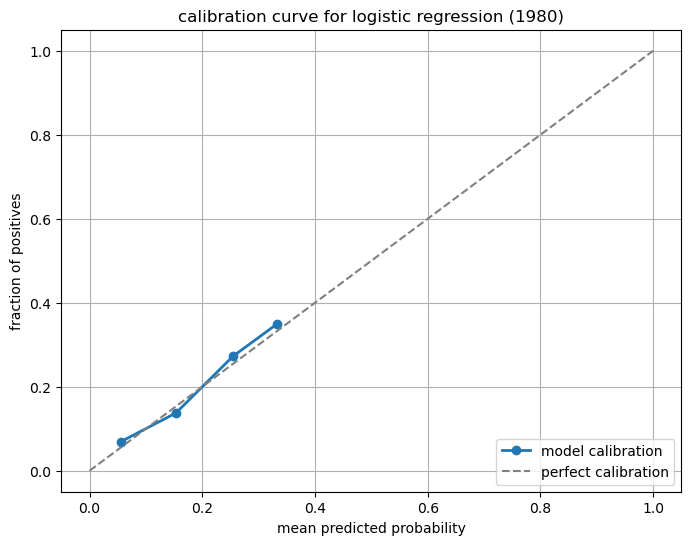

(0.0001299999999999999, 0.0408]    120
(0.0408, 0.08]                     163
(0.08, 0.119]                      165
(0.119, 0.158]                     217
(0.158, 0.198]                     213
(0.198, 0.237]                     244
(0.237, 0.276]                     300
(0.276, 0.315]                     417
(0.315, 0.355]                     437
(0.355, 0.394]                     116
Name: count, dtype: int64


In [80]:
prob_true_lr_1980, prob_pred_lr_1980 = calibration_curve(binary_series_1980, lr_draw_1980, n_bins = 10, strategy = "uniform")
plt.figure(figsize=(8,6))
plt.plot(prob_pred_lr_1980, prob_true_lr_1980, marker = "o", linewidth=2, label = "model calibration")
plt.plot([0, 1], [0,1], linestyle = "--", color = "gray", label = "perfect calibration")
plt.xlabel("mean predicted probability")
plt.ylabel("fraction of positives")
plt.title("calibration curve for logistic regression (1980)" )
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()


vals = pd.cut(lr_draw_1980, bins=10, include_lowest = True )
bins_count = vals.value_counts().sort_index()

print(bins_count) 



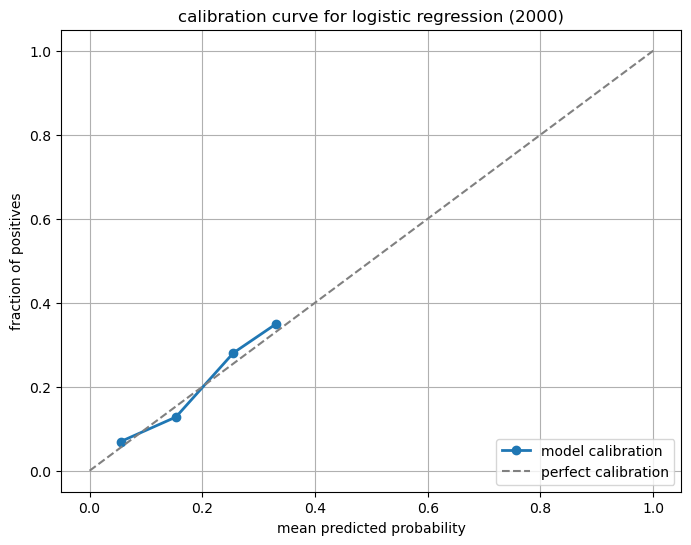

(0.00030999999999999995, 0.0404]    115
(0.0404, 0.0791]                    157
(0.0791, 0.118]                     162
(0.118, 0.157]                      220
(0.157, 0.195]                      206
(0.195, 0.234]                      246
(0.234, 0.273]                      311
(0.273, 0.311]                      406
(0.311, 0.35]                       429
(0.35, 0.389]                       140
Name: count, dtype: int64


In [81]:
prob_true_lr_2000, prob_pred_lr_2000 = calibration_curve(binary_series_2000, lr_draw_2000, n_bins = 10, strategy = "uniform")
plt.figure(figsize=(8,6))
plt.plot(prob_pred_lr_2000, prob_true_lr_2000, marker = "o", linewidth=2, label = "model calibration")
plt.plot([0, 1], [0,1], linestyle = "--", color = "gray", label = "perfect calibration")
plt.xlabel("mean predicted probability")
plt.ylabel("fraction of positives")
plt.title("calibration curve for logistic regression (2000)" )
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()


vals = pd.cut(lr_draw_2000, bins=10, include_lowest = True )
bins_count = vals.value_counts().sort_index()

print(bins_count) 


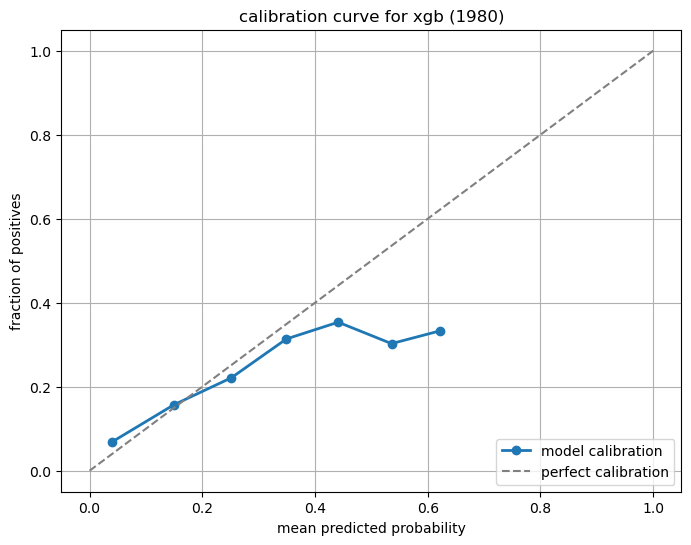

(-0.0015500000000000002, 0.0638]    276
(0.0638, 0.128]                     227
(0.128, 0.191]                      265
(0.191, 0.255]                      283
(0.255, 0.319]                      343
(0.319, 0.382]                      376
(0.382, 0.446]                      361
(0.446, 0.51]                       188
(0.51, 0.574]                        59
(0.574, 0.637]                       14
Name: count, dtype: int64


In [82]:
prob_true_xgb, prob_pred_xgb = calibration_curve(binary_series_1980, draw_probability_1980, n_bins = 10, strategy = "uniform")
plt.figure(figsize=(8,6))
plt.plot(prob_pred_xgb, prob_true_xgb, marker = "o", linewidth=2, label = "model calibration")
plt.plot([0, 1], [0,1], linestyle = "--", color = "gray", label = "perfect calibration")
plt.xlabel("mean predicted probability")
plt.ylabel("fraction of positives")
plt.title("calibration curve for xgb (1980)" )
plt.legend(loc = "lower right")
plt.grid(True)
plt.show() 



vals = pd.cut(draw_probability_1980, bins=10, include_lowest = True )
bins_count = vals.value_counts().sort_index()

print(bins_count) 

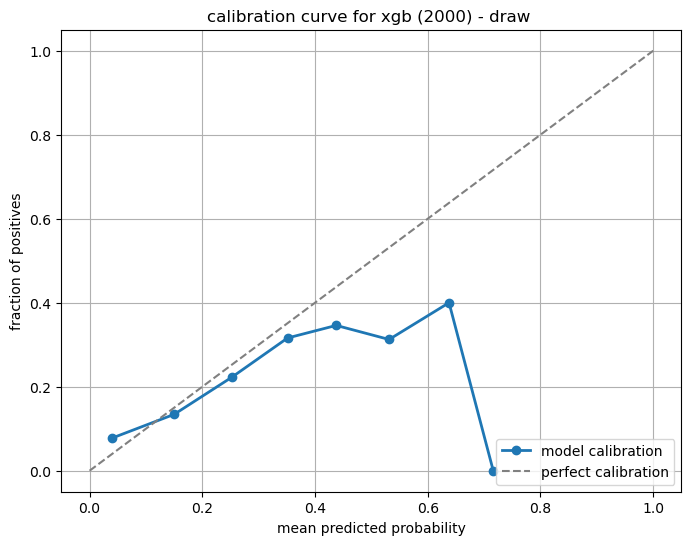

(-0.001363, 0.0719]    293
(0.0719, 0.144]        239
(0.144, 0.215]         270
(0.215, 0.287]         401
(0.287, 0.358]         441
(0.358, 0.43]          456
(0.43, 0.501]          233
(0.501, 0.573]          43
(0.573, 0.645]          11
(0.645, 0.716]           5
Name: count, dtype: int64


In [83]:
prob_true_xgb_2000, prob_pred_xgb_2000 = calibration_curve(binary_series_2000, draw_probability_2000, n_bins = 10, strategy = "uniform")
plt.figure(figsize=(8,6))
plt.plot(prob_pred_xgb_2000, prob_true_xgb_2000, marker = "o", linewidth=2, label = "model calibration")
plt.plot([0, 1], [0,1], linestyle = "--", color = "gray", label = "perfect calibration")
plt.xlabel("mean predicted probability")
plt.ylabel("fraction of positives")
plt.title("calibration curve for xgb (2000) - draw " )
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()


vals = pd.cut(draw_probability_2000, bins=10, include_lowest = True )
bins_count = vals.value_counts().sort_index()

print(bins_count) 


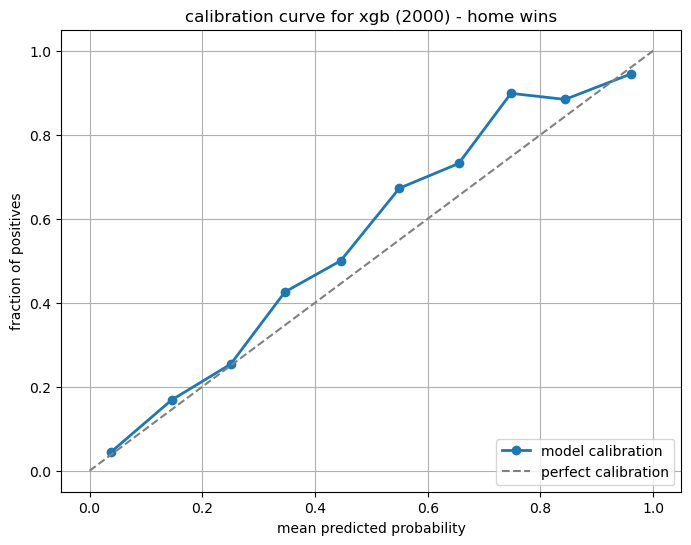

(-0.001499, 0.1]    956
(0.1, 0.2]          420
(0.2, 0.3]          260
(0.3, 0.4]          187
(0.4, 0.5]          123
(0.5, 0.599]        110
(0.599, 0.699]      106
(0.699, 0.799]       69
(0.799, 0.899]       71
(0.899, 0.999]       90
Name: count, dtype: int64


In [84]:
hwin_true_xgb_2000, hwin_pred_xgb_2000 = calibration_curve(binary_series_2000_hwin, hwin_probability_2000, n_bins = 10, strategy = "uniform")
plt.figure(figsize=(8,6))
plt.plot(hwin_pred_xgb_2000, hwin_true_xgb_2000, marker = "o", linewidth=2, label = "model calibration")
plt.plot([0, 1], [0,1], linestyle = "--", color = "gray", label = "perfect calibration")
plt.xlabel("mean predicted probability")
plt.ylabel("fraction of positives")
plt.title("calibration curve for xgb (2000) - home wins" )
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()


vals = pd.cut(hwin_probability_2000, bins=10, include_lowest = True )
bins_count = vals.value_counts().sort_index()

print(bins_count) 

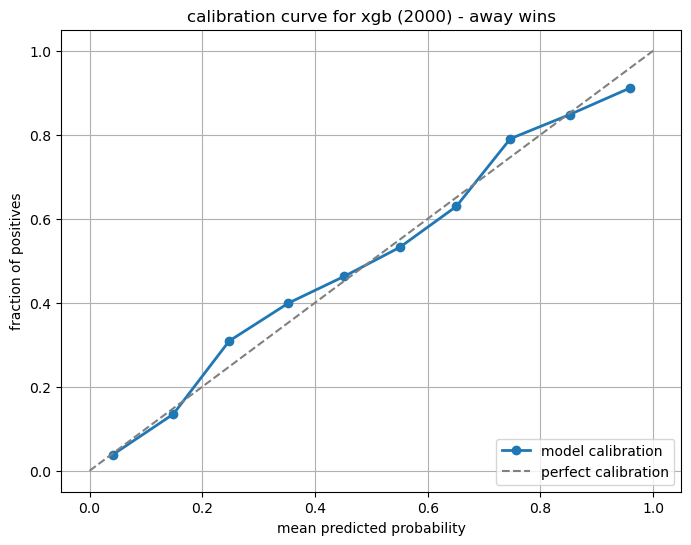

(-0.001526, 0.1]    365
(0.1, 0.2]          229
(0.2, 0.3]          204
(0.3, 0.4]          228
(0.4, 0.5]          215
(0.5, 0.6]          238
(0.6, 0.7]          239
(0.7, 0.799]        253
(0.799, 0.899]      171
(0.899, 0.999]      250
Name: count, dtype: int64


In [85]:
awin_true_xgb_2000, awin_pred_xgb_2000 = calibration_curve(binary_series_2000_awin, awin_probability_2000, n_bins = 10, strategy = "uniform")
plt.figure(figsize=(8,6))
plt.plot(awin_pred_xgb_2000, awin_true_xgb_2000, marker = "o", linewidth=2, label = "model calibration")
plt.plot([0, 1], [0,1], linestyle = "--", color = "gray", label = "perfect calibration")
plt.xlabel("mean predicted probability")
plt.ylabel("fraction of positives")
plt.title("calibration curve for xgb (2000) - away wins" )
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()


vals = pd.cut(awin_probability_2000, bins=10, include_lowest = True )
bins_count = vals.value_counts().sort_index()

print(bins_count) 

In [86]:

test_pred_2000 = xgb_2000.predict(X_test_2000) 
probs_2000 = xgb_2000.predict_proba(X_test_2000) 


print("\t classification report: 2000 test data")
print(classification_report(encoded_test_2000, test_pred_2000))






	 classification report: 2000 test data
              precision    recall  f1-score   support

           0       0.67      0.62      0.64       890
           1       0.35      0.27      0.31       742
           2       0.72      0.83      0.77      1510

    accuracy                           0.64      3142
   macro avg       0.58      0.57      0.57      3142
weighted avg       0.62      0.64      0.63      3142



In [87]:
classes, counts = np.unique(test_pred_2000, return_counts = True) 
freq = dict(zip(classes, counts)) 
print(freq) 

{np.int64(0): np.int64(819), np.int64(1): np.int64(570), np.int64(2): np.int64(1753)}


In [88]:
print(probs_2000) 

[[0.4823922  0.37331873 0.1442891 ]
 [0.28165966 0.30234098 0.41599932]
 [0.24284878 0.4078483  0.34930292]
 ...
 [0.34380323 0.44387227 0.21232451]
 [0.26842213 0.2668777  0.4647002 ]
 [0.09681235 0.45109618 0.45209143]]


In [ ]:
for index, label in enumerate(le.classes_):
    print(f"{index}: {label}")


0: away_win
1: draw
2: home_win


In [90]:
xgb_2000.save_model("../src/models/xgboost_worldcup_model.json")